<a href="https://colab.research.google.com/github/jessieaha/CAMS_dust_deduction_tool/blob/main/Dust_deduction_tool_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Dust service Tool

This notebook presents a prototype of the <u>**CAMS Natural Dust service Tool**</u> designed to support EU Member States in identifying and assessing natural contributions from dust to PM10 concentrations, as requested by Article 16 of the Air Quality Directive (AAQD 2024/2881). The tool aims to calculate and subtract these natural dust contributions from measured PM10 concentrations to provide corrected PM10 surface concentrations.

> AAQD (2024/2881) Article 16: Member states are requested to identify a) zones where exceedances of limit values for a given pollutant are attributable to natural sources and b) average exposure territorial units, where exceedances of the level determined by the average exposure reduction obligations are attributable to natural sources.

This *natural dust service tool prototype* is based on the methodology provided in the European Commission DG-ENV  guidelines ([sec 2011-0208](https://data.consilium.europa.eu/doc/document/ST%206771%202011%20INIT/EN/pdf)) for the assessment of the natural contributions from dust, which needs to be followed to allow subtraction of these contributions from the reported PM concentrations.
For flagging the presence of natural dust the CAMS interim reanalysis dust product is used.

This prototype is demonstrating the methodology and applications of the tool for 2024 and daily EEA data in Spain.

# Outline
- [ 1 - Import Packages ](#1)
- [ 2 - Country selection and Threshold settings](#2)
- [ 3 - Data preparation ](#3)
- [ 4 - Flag dust days with CAMS data](#4)
- [ 5 - Calculate dust for days with dust and exceedance](#5)
- [ 6 - Table with results](#6)
- [ 7 - Visualization](#7)

<a name="1"></a>
## 1 - Import Packages

Output should show in the lastline:

> util.py has been imported




In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import requests
import os
import glob
import zipfile
import calendar
#!pip install xarray netcdf4
import xarray as xr
!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import urllib.request
import json
import io
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
raw_url="https://raw.githubusercontent.com/jessieaha/CAMS_dust_deduction_tool/main/util.py"
dest = Path('util.py')
urllib.request.urlretrieve(raw_url, dest)
from util import *
print(until_check())

util.py has been imported



<details>
<summary><font size="2" color="darkgreen"><b>Please Click here if errors appear</b></font></summary>
Remove <font size="2" color="blue"> <b>%%capture</b></font> and output should show in the end:

> util.py has been imported

If functions are modified in util.py please reload the file use the code below
```
import sys, importlib, os, inspect
import util
importlib.invalidate_caches()
if 'util' in sys.modules:
    del sys.modules['util']
import util
importlib.reload(util)  # extra safety

# Double-check the function exists and from which file it's loaded
print("Has function?", hasattr(util, 'plot_station_timeseries'))
if hasattr(util, 'plot_station_timeseries'):
    print(inspect.getsource(util.plot_station_timeseries)[:400])  # peek at the first lines

```
If one of the modules are not loading  try

```
pip install xxxx
```
If you plan to run this notebook in the VScode or in HPC environment, the widget from interactive plot might not work but you can modify the code by inputing correct column to generate static plots. Cheers!




<a name="2"></a>
## 2- Country selection and Threshold settings
Choose the country of interest for downloading the observation data. Note that only SPAIN (ES) is available in this prototype based on a predownloaded daily EEA dataset.

In the final tool you will be able to select other countries to download daily or hourly EEA datasets (E1a or E2a) for chosen year. You will also be able to choose to use your own observation dataset.
<center>


| Country Code | Country Name           | Country Code | Country Name           |
|-------------|-------------------------|-------------|-------------------------|
| AD          | Andorra                | IT          | Italy                  |
| AL          | Albania                | LT          | Lithuania              |
| AT          | Austria                | LU          | Luxembourg             |
| BA          | Bosnia and Herzegovina | LV          | Latvia                 |
| BE          | Belgium                | ME          | Montenegro             |
| BG          | Bulgaria               | MK          | North Macedonia        |
| CH          | Switzerland            | MT          | Malta                  |
| CY          | Cyprus                 | NL          | Netherlands            |
| CZ          | Czechia                | NO          | Norway                 |
| DE          | Germany                | PL          | Poland                 |
| DK          | Denmark                | PT          | Portugal               |
| EE          | Estonia                | RO          | Romania                |
| ES          | Spain                  | RS          | Serbia                 |
| FI          | Finland                | SE          | Sweden                 |
| FR          | France                 | SI          | Slovenia               |
| GB          | United Kingdom         | SK          | Slovakia               |
| GR          | Greece                 | XK          | Kosovo                |  
| HR          | Croatia                |             |                         |
| HU          | Hungary                |             |                         |
| IE          | Ireland                |             |                         |
| IS          | Iceland                |             |                         |

</center>

dataset value
1. Unverified data transmitted continuously (Up-To-Date/UTD/E2a) data from the
beginning of 2023.
2. Verified data (E1a) from 2013 to 2022 reported by countries by 30 September each year for
the previous year.
3. Historical Airbase data delivered between 2002 and 2012 before Air Quality
Directive 2008/50/EC entered into force.
4. Downscaled CAMS forecast at station level
5. Gap-filled E2a, using linear interpolation for smaller gaps, and a regressor based on
similar stations for larger ones.


In [32]:
project_dir          = '.'
YEAR                 = 2025      # int: target year
EEA_temporal_flag    = 'hour'    # hour or day
dataset              = 'E2a'
POLLUTANT            = 'PM10'
EEA_folder_path      = f'EEA_{POLLUTANT}/{YEAR}/{dataset}/{EEA_temporal_flag}'
VAR                  = 'dust'
CAMS_folder_path     = f'{project_dir}/IRA_{VAR}/'
DOWNLOAD_EEA         = False
DOWNLOAD_CAMS        = False
COMPUTE_CAMS_DAILY   = False
USE_GOOGLE_DRIVE     = True
Countries            = ["AD", "AL", "AT", "BA", "BE", "BG", "CH", "CY", "CZ", "DE", "DK", "EE", "ES", "FI", "FR", "GB", "GR", "HR", "HU", "IE", "IS", "IT", "LT", "LU", "LV", "ME", "MK", "MT", "NL", "NO", "PL", "PT", "RO", "RS", "SE", "SI", "SK", "XK"]
# cams_dust_threshold  = 5
# PM10_daily_threshold = 50
LOAD_PARQUET_DATA    = False

if USE_GOOGLE_DRIVE:
  from google.colab import drive
  import os
  if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
  gdrive_output_dir = '/content/drive/MyDrive/CAMS_Tool_output'
  os.makedirs(gdrive_output_dir, exist_ok=True)
  print(f"Google Drive output directory: {gdrive_output_dir}")

Google Drive output directory: /content/drive/MyDrive/CAMS_Tool_output


In [33]:
if (DOWNLOAD_EEA):
    from datetime import datetime
    # Specify download path
    os.makedirs(EEA_folder_path, exist_ok=True)

    # Determine the target path for the zip file
    if USE_GOOGLE_DRIVE:
        zip_target_path = os.path.join(gdrive_output_dir, f"EEA_{POLLUTANT}/{EEA_temporal_flag}/{dataset}_{POLLUTANT}_{EEA_temporal_flag}_{YEAR}.zip")
        # Create the directory structure in Google Drive
        os.makedirs(os.path.dirname(zip_target_path), exist_ok=True)
        local_extract_path = EEA_folder_path # Extract to local Colab env
        os.makedirs(local_extract_path, exist_ok=True)
    else:
        zip_target_path = os.path.join(EEA_folder_path,f"EEA_{POLLUTANT}/{EEA_temporal_flag}/{dataset}_{POLLUTANT}_{EEA_temporal_flag}_{YEAR}.zip")
        os.makedirs(os.path.dirname(zip_target_path), exist_ok=True)
        local_extract_path = EEA_folder_path

    if USE_GOOGLE_DRIVE and os.path.exists(zip_target_path):
        print(f"Loading EEA data from Google Drive: {zip_target_path}")
        with zipfile.ZipFile(zip_target_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_path)
        print("EEA data loaded and extracted from Google Drive.")
    else:
        apiUrl = "https://eeadmz1-downloads-api-appservice.azurewebsites.net/"
        endpoint = "ParquetFile/async"

        # Map dataset string to EEA API ID
        # 1: E2a (UTD), 2: E1a (Verified), 3: Historical
        dataset_mapping = {
            'E2a': 1,
            'UTD': 1,
            'E1a': 2,
            'Historical': 3
        }
        eea_dataset_id = dataset_mapping.get(dataset, 2) # Default to 2 if not found

        request_body = {
            "countries": Countries,
            "cities": [],
            "pollutants": [POLLUTANT],
            "dataset": eea_dataset_id,
            "dateTimeStart": f"{YEAR-1}-12-14T00:00:00Z",
            "dateTimeEnd": f"{YEAR}-12-31T23:59:59Z",
            "aggregationType": EEA_temporal_flag,
            "email": ""
        }

        response = requests.post(f"{apiUrl}{endpoint}", json=request_body)
        downloadFile = response.text
        print(f"Requesting download from: {downloadFile}")

        t_start = datetime.now()
        while True:
            if (datetime.now() - t_start).total_seconds() > 3600:  # stop after 1 hour if the file has not been created
                break
            parquetResponse = requests.get(downloadFile)
            if parquetResponse.status_code == 404:
                time.sleep(20)
            else:
                break

        with open(zip_target_path, "wb") as fp:
            fp.write(parquetResponse.content)

        print(f"Download Successful: {zip_target_path}")

        with zipfile.ZipFile(zip_target_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_path)
        print(f"EEA data extracted to {local_extract_path}")
else:
    # Logic for when DOWNLOAD_EEA is False
    if USE_GOOGLE_DRIVE:
        zip_target_path = os.path.join(gdrive_output_dir, f"EEA_{POLLUTANT}/{EEA_temporal_flag}/{dataset}_{POLLUTANT}_{EEA_temporal_flag}_{YEAR}.zip")
    else:
        zip_target_path = os.path.join(EEA_folder_path, f"{dataset}_{POLLUTANT}_{YEAR}.zip")

    local_extract_path = EEA_folder_path

    if os.path.exists(zip_target_path):
        print(f"DOWNLOAD_EEA is False. Extracting existing zip found at: {zip_target_path}")
        os.makedirs(local_extract_path, exist_ok=True)
        with zipfile.ZipFile(zip_target_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_path)
        print(f"Data extracted to {local_extract_path}")
    else:
        print(f"DOWNLOAD_EEA is False, but no existing zip file was found at {zip_target_path}. Please set DOWNLOAD_EEA to True.")

DOWNLOAD_EEA is False. Extracting existing zip found at: /content/drive/MyDrive/CAMS_Tool_output/EEA_PM10/hour/E2a_PM10_hour_2025.zip
Data extracted to EEA_PM10/2025/E2a/hour


Please go to https://cds.climate.copernicus.eu/how-to-api to see how to use cdsapi
if you already have an account but forgot your key please go to your profile and copy API key like below.
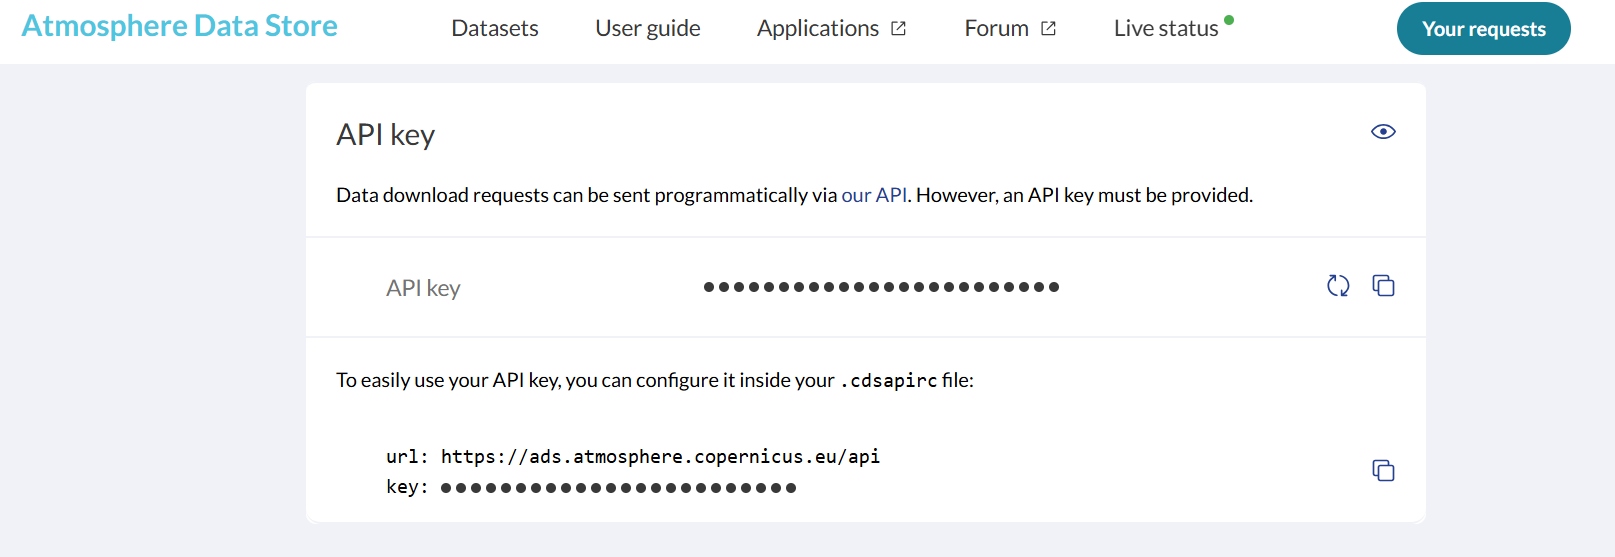

if you need to create or regenerate login key for ads or cds, please uncomment the cell below
If error appeared please try !pip install --user "cdsapi>=0.7.7"

In [34]:
if (DOWNLOAD_CAMS):
  # if you want to regenerate your api key, uncomment below:
  # !rm  ~/.cdsapirc
  # Ask for user input
  path = os.path.expanduser('~/.cdsapirc')

  # 1. Check if the file already exists
  if os.path.exists(path):
      print(f"Skipping: Configuration file already exists at {path}")
  else:
    api_key = input("Enter your Copernicus CDS API Key: ")

    # Define the content and path
    path = os.path.expanduser('~/.cdsapirc')
    content = f"""url: https://ads.atmosphere.copernicus.eu/api
    key: {api_key}"""
    # content = "url: https://ads.atmosphere.copernicus.eu/api \nkey:"

    # Write the file
    with open(path, 'w') as f:
        f.write(content)

    print(f"\nSuccess! .cdsapirc has been created at {path}")
  !ls -a ~ | grep .cdsapirc
  !cat  ~/.cdsapirc
  !pip install --user "cdsapi>=0.7.7"

In [35]:
if (DOWNLOAD_CAMS):
    ### First make sure cdsapi can be loaded correctly
    import site
    from importlib import reload

    # Force Python to look at the newly installed packages
    reload(site)

    try:
        import cdsapi
        # Attempt to initialize a client to verify it works
        client = cdsapi.Client(quiet=True)
        print("Success! cdsapi is now imported and the client is initialized.")
    except ImportError:
        print("Still unable to import. Please try restarting the session via: Runtime -> Restart session")
    except Exception as e:
        print(f"cdsapi is imported but failed to initialize: {e}")
    #### end of loading

VAR = "dust"

# Determine base CAMS folder path
if USE_GOOGLE_DRIVE:
    cams_base_path = os.path.join(gdrive_output_dir, f'IRA_{VAR}')
else:
    cams_base_path = f'{project_dir}/IRA_{VAR}'

# Create directories
os.makedirs(cams_base_path, exist_ok=True)
local_extract_path = f'{project_dir}/IRA_{VAR}'
os.makedirs(local_extract_path, exist_ok=True)

cams_downloads = [
    {"filename": f"CAMS_IRA_{(YEAR-1)}_12.zip", "year": [f"{(YEAR-1)}"], "month": ["12"]},
    {"filename": f"CAMS_IRA_{(YEAR)}_q1.zip", "year": [f"{YEAR}"], "month": ["01","02","03"]},
    {"filename": f"CAMS_IRA_{(YEAR)}_q2.zip", "year": [f"{YEAR}"], "month": ["04","05","06"]},
    {"filename": f"CAMS_IRA_{(YEAR)}_q3.zip", "year": [f"{YEAR}"], "month": ["07","08","09"]},
    {"filename": f"CAMS_IRA_{(YEAR)}_q4.zip", "year": [f"{YEAR}"], "month": ["10","11","12"]}
]

dataset_name = "cams-europe-air-quality-reanalyses"

# Only run download/extract logic if we actually need to compute daily means from raw files
if COMPUTE_CAMS_DAILY:
    for config in cams_downloads:
        zip_file_path = os.path.join(cams_base_path, config["filename"])

        # 1. Handle Downloads if requested and file missing
        if DOWNLOAD_CAMS and not os.path.exists(zip_file_path):
            import cdsapi
            client = cdsapi.Client()
            print(f"Downloading CAMS data to {zip_file_path}...")
            request = {
                "variable": [VAR],
                "model": ["ensemble"],
                "level": ["0"],
                "type": ["interim_reanalysis"],
                "year": config["year"],
                "month": config["month"]
            }
            client.retrieve(dataset_name, request).download(zip_file_path)
            print(f"Download Successful: {config['filename']}")

        # 2. Handle Extraction if file exists
        if os.path.exists(zip_file_path):
            # Check if contents are already extracted by looking for one of the expected NetCDF files
            # Typically named: cams.eaq.ira.ENSa.dust.l0.YYYY-MM.nc
            sample_month = config["month"][0]
            sample_year = config["year"][0]
            expected_file = os.path.join(local_extract_path, f"cams.eaq.ira.ENSa.{VAR}.l0.{sample_year}-{sample_month}.nc")

            if not os.path.exists(expected_file):
                print(f"Extracting CAMS data from: {zip_file_path}")
                with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                    zip_ref.extractall(local_extract_path)
                print(f"CAMS data extracted to {local_extract_path}.")
            else:
                print(f"CAMS data for {config['filename']} already extracted at {local_extract_path}. Skipping.")
        else:
            print(f"CAMS data file not found: {zip_file_path}. Set DOWNLOAD_CAMS=True to fetch it.")
else:
    print("COMPUTE_CAMS_DAILY is False. Skipping CAMS raw data download and extraction.")

COMPUTE_CAMS_DAILY is False. Skipping CAMS raw data download and extraction.



For flexibility considering changes in future guidelines including different limit values, the user can modify the threshold here:


1.   Set the CAMS dust concentration threshold used for flagging a day as 'dust day'
2.   Set the threshold for the PM10 limit value (you can for example choose to use the old or new AAQD limit values)
3.   Set the minimum % of data coverage to allow inclusion of the eea measurements



In [36]:
##################User Editable######################
CAMS_dust_threshold         = 5         # unit: µg/m3
PM10_daily_threshold        = 50        # 50 µg m-3
Station_Temporal_coverage   = 65        # in % of temporal coverage per whole year for each EEA station
Basline_MA_days             = 6         # how many neighboring days without dust should be considered
##################STOP Editing######################

<a name="3"></a>
## 3- Data preparation
In this step the EEA data including metadata is downloaded, filtered for validity, verification status and data coverage (using the minimum value set in step 2).

Note that in the prototype, we only provide pre-downloaded EEA daily air quality data for Spain as a demonstration.

In the final tool, you will be able to use the tool to download any EEA dataset—either hourly or daily. Please note that the final tool may differ slightly from this prototype, as the prototype is optimized for efficiency and speed.

[Go to download script](#download)

### Load EEA data
Please use the preprocessed data for hourly dataset

### Filter for validity and verification
Validity and Verification definitions from EEA:
|ID     | Label                                       | Status    | Status Modified | Notation |
|-------|---------------------------------------------|-----------|-----------------|----------|
| -99   | Not valid due to station maintenance or calibration       | Valid           | 22.03.2013 | -99 |
| -1    | Not valid                                                 | Valid           | 22.03.2013 | -1  |
| 1     | Valid                                                     | Valid           | 22.03.2013 | 1   |
| 2     | Valid, but below detection limit measurement value given  | Valid           | 22.03.2013 | 2   |
| 3     | Valid, but below detection limit and number replaced by 0.5*detection limit | Valid           | 22.03.2013 | 3   |
| 4     | Valid (Ozone only) using CCQM.O3.2019                     | Valid           | 04.07.2024 | 4   |


#### Verified code
| Id | Label                  | Status | Status Modified | Notation |
|----|------------------------|--------|-----------------|----------|
| 1  | Verified              | Valid  | 22.03.2013      | 1        |
| 2  | Preliminary verified  | Valid  | 22.03.2013      | 2        |
| 3  | Not verified          | Valid  | 22.03.2013      | 3        |
 <br>

### Filter temporal range
Only keep stations that contain chosen year data. Predownloaded set covers also some period before and/or after the chosen year for later computation of moving averages.
EEA hourly data are formatted already in CET or UTC+1 timezone

In [56]:
import gc
import pandas as pd
import os
import glob

def eea_to_utc(series: pd.Series, source_tz: str = "CET") -> pd.Series:
    s = pd.to_datetime(series, errors="coerce")
    def _localize_if_naive(x):
        if pd.isna(x): return x
        return x.tz_localize("Etc/GMT-1") if x.tzinfo is None else x
    return s.apply(_localize_if_naive).dt.tz_convert("UTC")

if EEA_temporal_flag == 'hour':
    search_path = os.path.join(EEA_folder_path, "**/*.parquet")
    parquet_files = glob.glob(search_path, recursive=True)

    if parquet_files:
        needed_cols = ['Value', 'Validity', 'Verification', 'AggType', 'Start', 'Samplingpoint', 'Unit', 'Pollutant']

        dataframes = []
        for file in parquet_files:
            df_tmp = pd.read_parquet(file, columns=needed_cols)
            df_tmp['Value'] = pd.to_numeric(df_tmp['Value'], errors='coerce').astype('float32')
            df_tmp['Samplingpoint'] = df_tmp['Samplingpoint'].astype('category')
            df_tmp['Pollutant'] = df_tmp['Pollutant'].astype('category')
            dataframes.append(df_tmp)

        obs = pd.concat(dataframes, ignore_index=True)
        del dataframes
        gc.collect()

        obs['Validity'] = pd.to_numeric(obs['Validity'], errors='coerce').astype('int8')
        obs['Verification'] = pd.to_numeric(obs['Verification'], errors='coerce').astype('int8')
        obs['AggType'] = obs['AggType'].astype('category')
        obs['Start'] = eea_to_utc(obs['Start'])

        print(f"Observations Before filtering: {obs.shape[0]:,}")

        # 4. In-place filtering for validity, verification, and non-negative values
        # Added (obs['Value'] >= 0) to remove negative sensor artifacts
        mask = (obs['Validity'] == 1) & (obs['Verification'] < 3) & (obs['AggType'].str.lower() == 'hour') & (obs['Value'] >= 0)
        obs = obs.loc[mask].drop(columns=['Verification', 'AggType'], errors='ignore')

        obs['day'] = obs['Start'].dt.floor('D')

        # Aggregate to daily values - using observed=False to handle categorical types
        hourly_to_daily_eea = (
            obs.groupby(['Pollutant', 'day', 'Samplingpoint'], sort=True, observed=False)
            .agg(daily_mean=('Value', 'mean'), n_hours=('Value', 'count'), unit=('Unit', 'first'))
            .reset_index()
        )

        # Only keep full 24-hour days to ensure daily mean quality
        hourly_to_daily_eea = hourly_to_daily_eea[hourly_to_daily_eea['n_hours'] == 24]
        print(f"Final stations processed: {len(hourly_to_daily_eea['Samplingpoint'].unique())}")

        del obs
        gc.collect()
    else:
        print("Error: No parquet files found.")

Observations Before filtering: 20,917,389
Final stations processed: 1860


### Filter for data coverage per station

You can change the temporal coverage above in the [ 2 - Country Selection and Threshold settings ](#2)

Please download the metadata manually at https://discomap.eea.europa.eu/App/AQViewer/index.html?fqn=Airquality_Dissem.b2g.measurements

#### Load and merge metadata
add exact location and timezone to observational data

In [62]:
import calendar
import util

# Inject calendar into the util module namespace to resolve NameError
util.calendar = calendar

if EEA_temporal_flag == 'hour':
    # For the prototype, we use a lower coverage requirement or skip annual check if data is partial
    # Here we temporarily set min_pct to 0 to see the available data
    df_processed = filter_daily_by_coverage(hourly_to_daily_eea, reference_year=YEAR, min_pct=0, keep_coverage_columns=False)

    # Flag exceedance days with concentration above threshold
    df_processed['Exceedance'] = df_processed['daily_mean'] > PM10_daily_threshold

    print(f'Total stations found in dataset: {len(df_processed["Samplingpoint"].unique())}')

    # Determine correct metadata path based on storage configuration
    if USE_GOOGLE_DRIVE:
        metadata_path = os.path.join(gdrive_output_dir, 'DataExtract.csv')
    else:
        metadata_path = os.path.join(project_dir, 'DataExtract.csv')

    if os.path.exists(metadata_path):
        metadata = pd.read_csv(metadata_path, low_memory=False)
        # Prepare metadata join key
        metadata['Samplingpoint'] = metadata['Air Quality Station EoI Code'].str[:2] + '/' + metadata['Sampling Point Id']
        # Join with station coordinates
        stations_geo = metadata[['Samplingpoint', 'Longitude', 'Latitude', 'Altitude', 'Timezone']].drop_duplicates(subset=['Samplingpoint'])
        df_processed = df_processed.merge(stations_geo, on='Samplingpoint', how='left')
        print(f"Metadata successfully merged from: {metadata_path}")
    else:
        print(f"Warning: Metadata file 'DataExtract.csv' not found at {metadata_path}. Skipping spatial merge.")

elif EEA_temporal_flag == 'day':
    coverage_stats = calculate_data_coverage(obs, start=f'{YEAR}-01-01', end=f'{YEAR}-12-31', min_pct=Station_Temporal_coverage)
    sufficient_stations = coverage_stats.query('sufficient_coverage').index.tolist()
    df_processed = obs[obs['Samplingpoint'].isin(sufficient_stations)].copy()
    print(f"Stations after filtering: {len(sufficient_stations)}")

Total stations found in dataset: 1860
Metadata successfully merged from: /content/drive/MyDrive/CAMS_Tool_output/DataExtract.csv


In [63]:
# # Re-run the metadata merge with the local file
# if os.path.exists(local_metadata):
#     metadata = pd.read_csv(local_metadata, low_memory=False)
#     metadata['Samplingpoint'] = metadata['Air Quality Station EoI Code'].str[:2] + '/' + metadata['Sampling Point Id']
#     stations_geo = metadata[['Samplingpoint', 'Longitude', 'Latitude', 'Altitude', 'Timezone']].drop_duplicates(subset=['Samplingpoint'])

#     # Merge onto the processed dataframe (using the 0-pct version created previously)
#     df_processed = df_processed.merge(stations_geo, on='Samplingpoint', how='left')
#     print(f"Metadata successfully merged. Valid stations with coords: {df_processed['Longitude'].notna().sum()}")
# else:
#     print("Local metadata file missing, please check if the copy step succeeded.")

### Load CAMS data for hourly EEA data

Here the CAMS interim reanalysis dust data is downloaded and processed for selected country.

This step can be memory intensive. In this prototype we provide a smaller, pre‑processed CAMS dataset extracted at EEA station locations in Spain to make the workflow more manageable.

In the final natural dust service tool, users will be able to download the complete CAMS regional interim reanalysis dust data which will then be aggregated to daily values before interpolating to all stations in their dataframe. This process typically exceeds the free memory limits available on Google Colab, so we recommend running it on a local machine or an HPC environment.
To support repeated workflows, the final natural dust service tool is intended to include functionality to compute, save, and reload these processed datasets for future use.

For using hourly aggregation of EEA data, we can first aggregate the CAMS data to daily in UTC then EEA stations to UTC daily as well.  
For daily EEA data, please use the preprocessor and load both cams data and eea data together

In [64]:
##############################################
##############cams data for hourly############
##############################################
if EEA_temporal_flag=='hour':
    # Target output file path
    if USE_GOOGLE_DRIVE:
        daily_cams_path = os.path.join(gdrive_output_dir, f'IRA_{VAR}/cams_dust_daily_mean.nc')
    else:
        daily_cams_path = os.path.join(project_dir, f"IRA_{VAR}/cams_dust_daily_mean.nc")

    # Check if we should compute or just load
    if COMPUTE_CAMS_DAILY:
        netcdf_files = np.sort(glob.glob(os.path.join(project_dir, f'IRA_{VAR}/cams.eaq.ira.ENSa.dust*%s*.nc'%(YEAR))))
        print(f"Found {len(netcdf_files)} source files for processing.")

        datasets = []
        for f in netcdf_files:
            try:
                # Use chunks to enable dask-backed lazy loading to save RAM
                ds = xr.open_dataset(f, chunks={'time': 24, 'lat': 100, 'lon': 100})
                datasets.append(ds)
            except Exception as e:
                print(f"Error opening {f}: {e}")

        if datasets:
            print("Aligning and combining datasets...")
            master_lat = datasets[0].lat
            master_lon = datasets[0].lon

            aligned_ds = []
            for ds in datasets:
                if not (ds.lat.equals(master_lat) and ds.lon.equals(master_lon)):
                    ds = ds.interp(lat=master_lat, lon=master_lon, method="nearest")
                aligned_ds.append(ds)

            cams = xr.concat(aligned_ds, dim='time').sortby('time')

            print("Resampling to daily mean...")
            daily_cams = cams.resample(time='1D').mean(keep_attrs=False).compute()

            # Strip attributes to prevent UnicodeEncodeError during save
            daily_cams.attrs = {}
            for var in daily_cams.variables:
                daily_cams[var].attrs = {}

            os.makedirs(os.path.dirname(daily_cams_path), exist_ok=True)
            print(f"Saving processed file to {daily_cams_path}...")
            daily_cams.to_netcdf(daily_cams_path)
            print(f"Saved daily means successfully.")
            cams.close()
        else:
            print("No source datasets were found to process.")
    else:
        if os.path.exists(daily_cams_path):
            print(f"Loading existing daily mean file from: {daily_cams_path}")
            # Use chunks here even when loading the processed file
            daily_cams = xr.open_mfdataset(daily_cams_path, chunks={'time': 'auto'})
            print(f'cams dust unit: {daily_cams["dust"].attrs.get("units", "N/A")}')
            print(f'cams dust dimension: {daily_cams["dust"].dims}')
        else:
            print(f"Daily mean file not found and COMPUTE_CAMS_DAILY is False.")

Loading existing daily mean file from: /content/drive/MyDrive/CAMS_Tool_output/IRA_dust/cams_dust_daily_mean.nc
cams dust unit: N/A
cams dust dimension: ('time', 'lat', 'lon')


In [65]:
if EEA_temporal_flag == 'hour':
    # cams: your xarray.Dataset with hourly dust
    # df_processed: your daily DataFrame
    print('Filtering stations outside CAMS domain and interpolating CAMS data...')

    # 1. Get CAMS spatial bounds
    lat_min, lat_max = daily_cams.lat.min().item(), daily_cams.lat.max().item()
    lon_min, lon_max = daily_cams.lon.min().item(), daily_cams.lon.max().item()

    # 2. Filter df_processed to only include stations within the CAMS domain
    # This prevents interpolation errors and ensures data consistency
    stations_before = len(df_processed['Samplingpoint'].unique())
    df_processed = df_processed[
        (df_processed['Latitude'] >= lat_min) & (df_processed['Latitude'] <= lat_max) &
        (df_processed['Longitude'] >= lon_min) & (df_processed['Longitude'] <= lon_max)
    ].copy()
    stations_after = len(df_processed['Samplingpoint'].unique())

    print(f"Stations filtered: {stations_before - stations_after} removed, {stations_after} remain within CAMS domain.")

    # 3. Interpolate cams data to the remaining station locations
    df = add_cams_daily_dust_by_station(
        cams_ds=daily_cams,
        df=df_processed,
        var_name='dust',
        time_col='day',
        lat_col='Latitude',
        lon_col='Longitude',
        station_col='Samplingpoint',
        spatial_method='linear'
    )
else:
    df = df_processed.rename(columns={'Value': 'daily_mean', 'Start': 'day'})

display(df.head())

Filtering stations outside CAMS domain and interpolating CAMS data...
Stations filtered: 32 removed, 1828 remain within CAMS domain.


,Pollutant,day,Samplingpoint,daily_mean,n_hours,unit,year,Exceedance,Longitude,Latitude,Altitude,Timezone,cams_dust
0,5,2025-01-01,AT/SPO.01.0003.3903.5.1,29.519384,24,ug.m-3,2025,False,17.07032,48.10915,136.0,UTC+01,0.516931
1,5,2025-01-01,AT/SPO.01.0006.68635.5.1,46.398083,24,ug.m-3,2025,False,16.22068,47.27836,308.0,UTC+01,0.683700
2,5,2025-01-01,AT/SPO.02.F202.56347.5.1,7.952917,24,ug.m-3,2025,False,14.52998,46.84283,810.0,UTC+01,0.833229
3,5,2025-01-01,AT/SPO.02.KA21.55784.5.1,100.540833,24,ug.m-3,2025,True,14.31806,46.62556,445.0,UTC+01,0.906192
4,5,2025-01-01,AT/SPO.02.KA71.64336.5.1,67.712082,24,ug.m-3,2025,True,14.29914,46.62662,445.0,UTC+01,0.909053


<a name="4"></a>
## 4- Flag dust days with CAMS data

In this step the CAMS interim reanalysis dust product is used to identify days impacted by natural dust.

You can experiment with the thresholds for flagging in the [ 2 - Country Selection and Threshold Settings](#2) although we do not recommend to change the threshold for the final results.

In [66]:
# Flag dust days for cams dust > 5 µg/m³ or treshold selected
df['dust_flag'] = df['cams_dust'] > CAMS_dust_threshold
df['Exceedance'] = df['daily_mean'] > PM10_daily_threshold

print('Blow shows the new table with dust flag and Exceedance')
df.head()

Blow shows the new table with dust flag and Exceedance


,Pollutant,day,Samplingpoint,daily_mean,n_hours,unit,year,Exceedance,Longitude,Latitude,Altitude,Timezone,cams_dust,dust_flag
0,5,2025-01-01,AT/SPO.01.0003.3903.5.1,29.519384,24,ug.m-3,2025,False,17.07032,48.10915,136.0,UTC+01,0.516931,False
1,5,2025-01-01,AT/SPO.01.0006.68635.5.1,46.398083,24,ug.m-3,2025,False,16.22068,47.27836,308.0,UTC+01,0.683700,False
2,5,2025-01-01,AT/SPO.02.F202.56347.5.1,7.952917,24,ug.m-3,2025,False,14.52998,46.84283,810.0,UTC+01,0.833229,False
3,5,2025-01-01,AT/SPO.02.KA21.55784.5.1,100.540833,24,ug.m-3,2025,True,14.31806,46.62556,445.0,UTC+01,0.906192,False
4,5,2025-01-01,AT/SPO.02.KA71.64336.5.1,67.712082,24,ug.m-3,2025,True,14.29914,46.62662,445.0,UTC+01,0.909053,False


In [67]:
import pandas as pd

# Inspect the rows with negative values to see which stations/dates are problematic
negative_rows = df[df['daily_mean'] < 0]
print(f"Number of rows with negative daily_mean: {len(negative_rows)}")
if not negative_rows.empty:
    display(negative_rows.sort_values('daily_mean').head(10))
else:
    print("No negative values found in the current 'df' variable.")

Number of rows with negative daily_mean: 0
No negative values found in the current 'df' variable.


<a name="5"></a>
## 5 - Calculate dust for days with dust and exceedance
Based on the start day/time of the measurements, this cell below will calculate the rolling windows of 30 days moving average median (5oth percentile) for all non-dusty days.

This is considered as the background PM10 without dust.

In [68]:

# RAM optimization: Create a view of the target year only and drop unneeded rows immediately
df_target_year = df[(df['day'] >= f'{YEAR}-01-01') & (df['day'] < f'{YEAR+1}-01-01')].copy()

if df_target_year.empty and not df.empty:
    available_year = df['day'].dt.year.unique()[0]
    print(f"Warning: No data for {YEAR}. Using available data from {available_year}")
    df_target_year = df[(df['day'] >= f'{available_year}-01-01') & (df['day'] < f'{available_year+1}-01-01')].copy()

df_target_year['Samplingpoint'] = df_target_year['Samplingpoint'].astype('category')
df_target_year['PM10_median'] = np.nan
df_target_year['PM10_median'] = df_target_year['PM10_median'].astype('float32')

# Memory efficient station processing
for station in df_target_year['Samplingpoint'].cat.categories:
    st_all = df[df['Samplingpoint'] == station]
    if st_all.empty: continue

    st_curr = df_target_year[df_target_year['Samplingpoint'] == station]
    if st_curr.empty: continue

    # compute_station_baseline is expected to return a series
    med_series = compute_station_baseline(st_all, st_curr, time_col='day', value_col='daily_mean', neighbor_n= Basline_MA_days)
    df_target_year.loc[st_curr.index, 'PM10_median'] = med_series.values.astype('float32')

# Free up the master 'df' if no longer needed for annual calculations to save RAM
# del df
gc.collect()

82

Here, the tool calculates the natural dust contribution and removes it from the PM10 in cases where the station has a flagged dust day and the PM10 exceeds the selected treshold value.

In [69]:
# Ensure values are float32 for RAM efficiency
df_target_year['daily_mean'] = pd.to_numeric(df_target_year['daily_mean'], errors='coerce').astype('float32')
df_target_year['PM10_median'] = pd.to_numeric(df_target_year['PM10_median'], errors='coerce').astype('float32')

# Vectorized calculation to avoid loops
dust_mask = df_target_year['dust_flag'].fillna(False).astype(bool)

# Dust contribution: Value - baseline (only on dusty days)
df_target_year['Dust_contribution'] = np.where(
    dust_mask,
    df_target_year['daily_mean'] - df_target_year['PM10_median'],
    0.0
).astype('float32')

# Corrected PM10: baseline on dust days, original on others
df_target_year['corrected_PM10'] = np.where(
    dust_mask,
    df_target_year['PM10_median'],
    df_target_year['daily_mean']
).astype('float32')

print('Memory-efficient columns created: Dust_contribution, corrected_PM10')
gc.collect()

Memory-efficient columns created: Dust_contribution, corrected_PM10


0

Alternative methods of using cams dust only

Corrected Dust = $(1+ \frac{Observed PM_{10}-Renalaysis PM_{10}}{Reanalysis PM_{10}})\ x\ Reanalysis Dust$


In [70]:
# obs_2024 = df[(df['day'] >= '2024-01-01') & (df['day'] < '2025-01-01')].copy()
# # Ratio of (Observed Mean / CAMS Modeled PM10) * CAMS Dust
# calculation = (obs_2024['daily_mean'] / obs_2024['cams_pm10']) * obs_2024['cams_dust']

# # Apply only where dust_flag is True, otherwise keep original daily_mean (or NaN)
# obs_2024['dust'] = np.where(
#     (obs_2024['dust_flag'] == True) & (obs_2024['Exceedance'] == True),
#     calculation,
#     obs_2024['daily_mean'] # Or np.nan if you only want dust values
# )
# obs_2024['corrected_PM10'] = obs_2024['daily_mean'].astype(float)
# mask = obs_2024['dust_flag'] & obs_2024['Exceedance']
# obs_2024.loc[mask, 'corrected_PM10'] = obs_2024.loc[mask, 'daily_mean'] - obs_2024.loc[mask, 'dust']

### Check for negative data
Next, we check whether any negative values occur in the corrected PM10 dataset.

Using a 30‑day moving average can sometimes yield a higher “background” concentration than the concentration during the dust impacted day because the method relies on the median. During dust events, strong winds may actually reduce local PM10 levels at certain stations, meaning that some “dusty days” can appear cleaner than typical background days. As a result, the corrected PM₁₀ (which is calculated as the measured concentration minus the estimated background) can become negative.



In [71]:
negative_dust = df_target_year['Dust_contribution']<0
print(f'total negative days {negative_dust.sum()}, and proceed to correction ->')
df_target_year['Dust_contribution'] = df_target_year['Dust_contribution'].clip(lower=0)
negative_dust = df_target_year['Dust_contribution']<0
print(f'Now negative days {negative_dust.sum()}')


total negative days 15, and proceed to correction ->
Now negative days 0


## Save/Load the file option

In [72]:
import pyarrow as pa
import pyarrow.parquet as pq

if not LOAD_PARQUET_DATA:
    # Determine the output path for the parquet file
    if USE_GOOGLE_DRIVE:
        output_parquet = os.path.join(gdrive_output_dir, f'CAMS_dust_deduction_{dataset}_{EEA_temporal_flag}_{YEAR}_MA15.parquet')
    else:
        output_parquet = f'{project_dir}CAMS_dust_deduction_{dataset}_{EEA_temporal_flag}_{YEAR}.parquet'

    table = pa.Table.from_pandas(df_target_year)
    pqwriter = pq.ParquetWriter(output_parquet, table.schema, use_dictionary=True, compression='snappy')
    pqwriter.write_table(table)
    pqwriter.close()
    print(f'save to {output_parquet}')
else:
    # Determine the input path for the parquet file
    if USE_GOOGLE_DRIVE:
        in_parquet = os.path.join(gdrive_output_dir, f'CAMS_dust_deduction_{dataset}_{EEA_temporal_flag}_{YEAR}_MA{Basline_MA_days}.parquet')
    else:
        in_parquet = f'{project_dir}CAMS_dust_deduction_{dataset}_{EEA_temporal_flag}_{YEAR}_v2.parquet'

    print(f'open {in_parquet}')
    df_target_year = pd.read_parquet(in_parquet)

save to /content/drive/MyDrive/CAMS_Tool_output/CAMS_dust_deduction_E2a_hour_2025_MA15.parquet


In [83]:
df_target_year

,Pollutant,day,Samplingpoint,daily_mean,n_hours,unit,year,Exceedance,Longitude,Latitude,Altitude,Timezone,cams_dust,dust_flag,PM10_median,Dust_contribution,corrected_PM10,Dust_exceedance
0,5,2025-01-01,AT/SPO.01.0003.3903.5.1,29.519384,24,ug.m-3,2025,False,17.07032,48.10915,136.0,UTC+01,0.516931,False,NaN,0.0,29.519384,False
1,5,2025-01-01,AT/SPO.01.0006.68635.5.1,46.398083,24,ug.m-3,2025,False,16.22068,47.27836,308.0,UTC+01,0.683700,False,NaN,0.0,46.398083,False
2,5,2025-01-01,AT/SPO.02.F202.56347.5.1,7.952917,24,ug.m-3,2025,False,14.52998,46.84283,810.0,UTC+01,0.833229,False,NaN,0.0,7.952917,False
3,5,2025-01-01,AT/SPO.02.KA21.55784.5.1,100.540833,24,ug.m-3,2025,True,14.31806,46.62556,445.0,UTC+01,0.906192,False,NaN,0.0,100.540833,False
4,5,2025-01-01,AT/SPO.02.KA71.64336.5.1,67.712082,24,ug.m-3,2025,True,14.29914,46.62662,445.0,UTC+01,0.909053,False,NaN,0.0,67.712082,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516477,5,2025-12-29,SI/SPO-SI0073A_00005_101,20.868750,24,ug.m-3,2025,False,14.36224,46.24179,388.0,UTC+01,0.085463,False,NaN,0.0,20.868750,False
516478,5,2025-12-29,SI/SPO-SI0074A_00005_102,28.268751,24,ug.m-3,2025,False,15.05395,46.15751,284.0,UTC+01,0.139101,False,NaN,0.0,28.268751,False
516479,5,2025-12-29,SI/SPO-SI0075A_00005_101,24.987501,24,ug.m-3,2025,False,14.48927,46.03749,293.0,UTC+01,0.140505,False,NaN,0.0,24.987501,False
516480,5,2025-12-29,SI/SPO-SI0076A_00005_101,30.762085,24,ug.m-3,2025,False,15.24624,46.23566,240.0,UTC+01,0.124037,False,NaN,0.0,30.762085,False


Next, we count the number of  exceedance days (*Exceedance_days*), exceedance days due to dust, i.e. where the exceedance is removed when we subtract the calculated natural dust contribution (*Dust_exceedance_days*, ) and corrected exceedance days after removing the calculated natural dust contributions (*NonDust_exceedance*)

In addition the annual average PM10 concentration observed by the EEA station is calculated aswell as the corrected annual average PM10 where the calculated natural dust contributions are removed (*corrected_PM10*).



In [73]:

# Dust exceedance flag (observed exceeds but corrected does not)
df_target_year['Dust_exceedance'] = (
    (df_target_year['daily_mean']  > PM10_daily_threshold) &
    (df_target_year['corrected_PM10'] <= PM10_daily_threshold)
)

# One-pass aggregation per station. For metadata columns that should be constant per station,
# we take 'first'. If they can vary, consider 'median' or a custom reducer.
station_table = (
    df_target_year
    .groupby('Samplingpoint', as_index=False)
    .agg(
        # Station metadata (kept from obs_2024)
        Latitude=('Latitude', 'first'),
        Longitude=('Longitude', 'first'),
        Altitude=('Altitude', 'first'),

        # Metrics
        Exceedance_days=('Exceedance', 'sum'),
        Dust_exceedance_days=('Dust_exceedance', 'sum'),
        Average_PM10=('daily_mean', 'mean'),
        Average_PM10_dust_removed=('corrected_PM10', 'mean'),
    )
)

# Derived metric
station_table['NonDust_exceedance'] = (
    station_table['Exceedance_days'] - station_table['Dust_exceedance_days']
)

# Optional: reorder columns for readability
station_table = station_table[
    [
        'Samplingpoint', 'Latitude', 'Longitude', 'Altitude',
        'Exceedance_days', 'Dust_exceedance_days', 'NonDust_exceedance',
        'Average_PM10', 'Average_PM10_dust_removed'
    ]
]
station_table


/tmp/ipykernel_74440/861118062.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Samplingpoint,Latitude,Longitude,Altitude,Exceedance_days,Dust_exceedance_days,NonDust_exceedance,Average_PM10,Average_PM10_dust_removed
0,AT/SPO.01.0003.3903.5.1,48.10915,17.07032,136.0,2,0,2,15.725847,15.610464
1,AT/SPO.01.0006.68635.5.1,47.27836,16.22068,308.0,1,0,1,16.058226,15.980159
2,AT/SPO.01.0007.64614.5.1,47.11789,16.16278,250.0,0,0,0,12.729745,12.729745
3,AT/SPO.02.F202.56347.5.1,46.84283,14.52998,810.0,0,0,0,10.874118,10.601388
4,AT/SPO.02.KA21.55784.5.1,46.62556,14.31806,445.0,4,0,4,18.124889,17.956486
...,...,...,...,...,...,...,...,...,...
1823,SI/SPO-SI0073A_00005_101,46.24179,14.36224,388.0,8,1,7,16.854328,16.649866
1824,SI/SPO-SI0074A_00005_102,46.15751,15.05395,284.0,5,0,5,14.516382,14.314303
1825,SI/SPO-SI0075A_00005_101,46.03749,14.48927,293.0,10,1,9,17.276577,17.040258
1826,SI/SPO-SI0076A_00005_101,46.23566,15.24624,240.0,14,0,14,18.237377,18.013508


<a name="6"></a>
## 6 - Final table with results for all stations

Below you find the final table containing all stations and their results.
You can save the data to a csv file.

The annual file contains for selected year for each station the number of exceedance days and annual average PM10 before and after natural dust subtraction.

The daily file contains the information per stations for each day of the year, including: measured PM10 concentration, occurence of exceedance of limit value, cams dust concentration, dust flag, background PM10, calculated natural dust contribution, corrected PM10 concentration and if the exceedance was due to natural dust.   

 The csv files can be found and downloaded under the file folder tab in the left colum of pictograms as can be seen in the screenshot below.

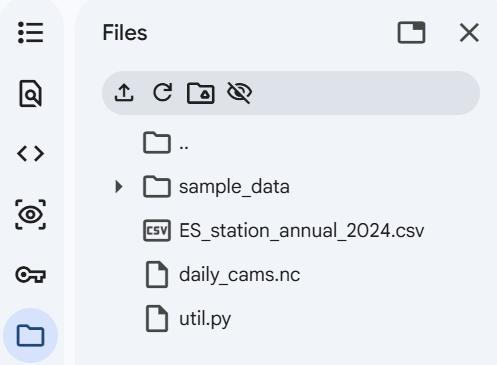


In [74]:
# If you would like to save this file please uncomment the line below
if (len(Countries)>=1):
    key = 'muti_countries'
else:
    key = Countries[0]

# Determine the output path for CSV files
if USE_GOOGLE_DRIVE:
    csv_output_dir = gdrive_output_dir
else:
    csv_output_dir = project_dir

station_table.to_csv(os.path.join(csv_output_dir, f'{key}_station_annual_{YEAR}.csv')) #aggregated stations average data
# df_2024.to_csv(os.path.join(csv_output_dir, f'{key}_station_daily_{YEAR}.csv')) #daily data

<a name="7"></a>
## 7 - Visualization
The tool provides both interactive and static plots.

If interactive animation like ipywidgets does not work in your environment, skip the cell below to go to the next cell to plot the static stations plot.



### Map - Corrected annual average PM10 and number of exceedances days

In this section, the corrected annual average PM10 (after subtraction of natural dust contributions) and corrected number of exceedances days (non-dust impacted exceedance days) per station is visualised in an interactive window. Move your cursor to the station location to show the results.

In [78]:

# Call the defined function to plot the interactive map with new options
plot_interactive_station_map(
    df=station_table,
    color_column='Average_PM10_dust_removed',
    size_column='NonDust_exceedance',
    color_type='continuous_scale', # Explicitly continuous
    colorscale='viridis',
    zoom=5,
    map_title='Corrected PM10 concentration (colorbar) and corrected nr. of exceedance days (size of dots)',
    colorbar_title='µg/m³',
    size_legend_min=1,
    size_legend_max=19,
    size_legend_steps=3,
    marker_size_range=[20, 40]
)




### Plot station timeseries


On the interactive map below you can select a station and click to plot the timeseries of measured and corrected PM10.

Color and size of the dots indicate the average PM10 concentration before removing the natural dust contribution.

In [84]:
interactive_map_widget = map_timeseries_clickable_plot(
    obs_df=df_target_year,
    year=YEAR,
    exceedance_threshold=PM10_daily_threshold,
    cams_dust_threshold=CAMS_dust_threshold,
    legend_title='Average observed PM10 (µg/m³)',
    legend_bins=7,
    legend_round=0,
    radius_range=(8, 16),
    station_column = 'Samplingpoint',
    time_column = 'Start',
    observed_pm10_col= 'daily_mean',
    corrected_pm10_col= 'corrected_PM10',
    cams_dust_col = 'cams_dust',
    dust_flag_col = 'dust_flag'
)
display(interactive_map_widget)

/content/util.py:406: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### Static timeseries
If the interactive maps above do not work you can copy the sations name and input below: Remember to uncomment the lines.

In [ ]:
# @title
########### USER INPUT ##############
stations = station_table['Samplingpoint'].unique()
print(stations)
station_name = stations[20] # specify station to plot
#####################################
# Plot timeseries for this station
fig, ax = plot_station_timeseries(station_name, df_2024,
                       year = YEAR,
                       time_column = 'day',
                       observed_pm10_col= 'daily_mean',
                       exceedance_threshold= PM10_daily_threshold,
                      cams_dust_threshold= 5
                      )

In [ ]:
df_2024['Latitude'].min()

### Static Map exceedance days

Static plot:

You can chose the column to plot from the station table.

For Custom color option:
https://matplotlib.org/stable/gallery/color/colormap_reference.html

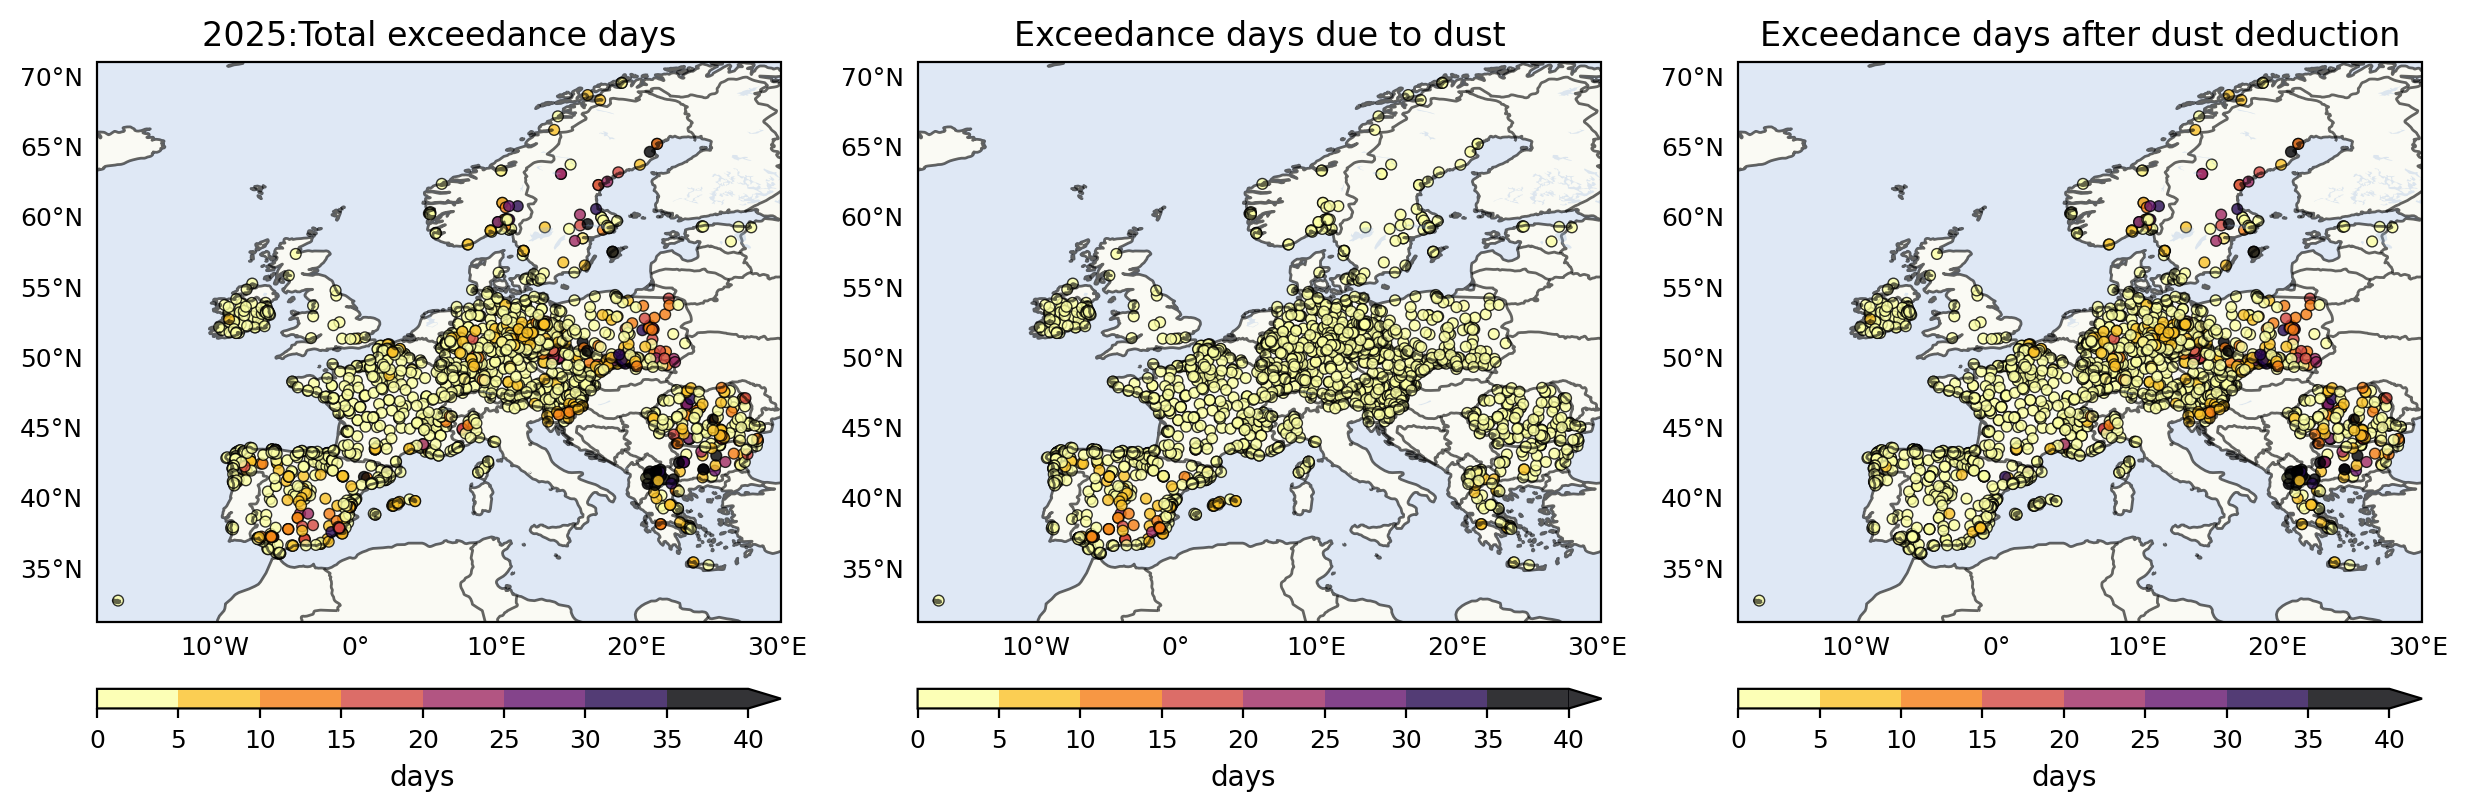

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# Removed: from mpl_toolkits.axes_grid1 import make_axes_locatable (not needed for the fix)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from typing import List, Optional, Literal, Sequence, Tuple

def plot_exceedance_maps_discrete(
    df: pd.DataFrame,
    columns_to_plot: Sequence[str],
    titles: Sequence[str],
    vmax: float,
    cbar_text: str,
    cmap_name: str = "gist_heat_r",
    n_colors: int = 10,
    extent: Optional[List[float]] = None,
    gridline : bool = False ,
    # --- NEW OPTIONS ---
    cbar_mode: Literal["single", "each"] = "single",
    cbar_orientation: Literal["vertical", "horizontal"] = "vertical",
    cbar_tick_mode: Literal["bounds", "centers"] = "bounds",
    cbar_size: str = "2.0%",     # only used when cbar_mode='each'
    cbar_pad: str = "1.5%",      # only used when cbar_mode='each'
    cbar_shrink: float = 0.85,   # used for cbar_mode='single'
    cbar_pad_single: float = 0.05,
    marker_size: float = 15,
    marker_alpha: float = 0.8,
    edgecolor: str = "black",
    edge_lw: float = 0.5,
    coast_alpha: float = 0.6,
    borders_alpha: float = 0.6,
    land_alpha: float = 0.3,
    ocean_alpha: float = 0.3,
    lakes_alpha: float = 0.3,
    title_fontsize: int = 12,
    label_fontsize: int = 9,
    figsize_per_panel: Tuple[float, float] = (5.0, 6.0),
    show: bool = True,
    savefile: Optional[str] = None,
    dpi: int = 200,
):
    """
    Plot maps of exceedance data with discrete color levels and flexible colorbar options.

    Parameters
    ----------
    df : DataFrame
        Must contain 'Latitude', 'Longitude', and columns in `columns_to_plot`.
    columns_to_plot : list[str]
        Column names in df to plot.
    titles : list[str]
        Titles for each subplot.
    vmax : float
        Upper bound for the discrete color scale (lower bound is 0).
    cbar_text : str
        Colorbar label text.
    cmap_name : str
        Matplotlib colormap name, e.g., 'gist_heat_r'.
    n_colors : int
        Number of discrete levels (creates n_colors+1 boundaries from 0..vmax).
    extent : [min_lon, max_lon, min_lat, max_lat] or None
        Map extent. If None, computed dynamically from df with a small buffer.

    Notes
    -----
    - `cbar_mode="single"`: one shared colorbar spanning all axes (fig.colorbar).
    - `cbar_mode="each"`: a separate narrow colorbar per subplot,
      attached via axes_grid1's `make_axes_locatable`.
    - `cbar_orientation` applies to both modes ('vertical' or 'horizontal').
    """
    assert len(columns_to_plot) == len(titles), "Number of columns must match number of titles."

    # --- Discrete colormap & normalization ---
    cmap = plt.get_cmap(cmap_name, n_colors)
    bounds = np.linspace(0, vmax, n_colors + 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # --- Figure & axes ---
    n_panels = len(columns_to_plot)
    fig_w = figsize_per_panel[0] * n_panels
    fig_h = figsize_per_panel[1]
    fig, axs = plt.subplots(
        1, n_panels,
        figsize=(fig_w, fig_h),
        subplot_kw={"projection": ccrs.PlateCarree()},
        dpi=dpi
    )

    # Ensure axs is iterable for 1 panel
    if n_panels == 1:
        axs = [axs]

    scatters = []

    # --- Plot each panel ---
    for i, (col, title) in enumerate(zip(columns_to_plot, titles)):
        ax = axs[i]

        # Scatter
        sc = ax.scatter(
            df["Longitude"], df["Latitude"],
            c=df[col],
            s=marker_size, cmap=cmap, norm=norm,
            transform=ccrs.PlateCarree(),
            alpha=marker_alpha, edgecolors=edgecolor, linewidth=edge_lw
        )
        scatters.append(sc)

        # Map features
        ax.add_feature(cfeature.COASTLINE, alpha=coast_alpha)
        ax.add_feature(cfeature.BORDERS, alpha=borders_alpha)
        ax.add_feature(cfeature.LAND, alpha=land_alpha)
        ax.add_feature(cfeature.OCEAN, alpha=ocean_alpha)
        ax.add_feature(cfeature.LAKES, alpha=lakes_alpha)

        # Extent
        if extent is None:
            buffer_val = 1.5
            dynamic_extent = [
                df["Longitude"].min() - buffer_val, df["Longitude"].max() + buffer_val,
                df["Latitude"].min() - buffer_val, df["Latitude"].max() + buffer_val
            ]
            ax.set_extent(dynamic_extent, crs=ccrs.PlateCarree())
        else:
            ax.set_extent(extent, crs=ccrs.PlateCarree())


        ax.set_title(title, fontsize=title_fontsize)
        if i == 0 or cbar_mode == "each":
            gl = ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False)
            gl.top_labels = False
            gl.right_labels = False
            gl.bottom_labels = True
            gl.left_labels = True
            # Hide grid lines (labels only)
            try:
                gl.xlines = gridline
                gl.ylines = gridline
            except Exception:
                pass
            gl.xlabel_style = {"size": label_fontsize}
            gl.ylabel_style = {"size": label_fontsize}
        else:
            gl = ax.gridlines(draw_labels=False, dms=False, x_inline=False, y_inline=False)
            try:
                gl.xlines = gridline
                gl.ylines = gridline
            except Exception:
                pass
    # --- Colorbar ticks: bounds vs centers ---
    if cbar_tick_mode == "bounds":
        ticks = bounds
    elif cbar_tick_mode == "centers":
        ticks = (bounds[:-1] + bounds[1:]) / 2.0
    else:
        raise ValueError("cbar_tick_mode must be 'bounds' or 'centers'.")

    # --- Build colorbar(s) ---
    if cbar_mode == "single":
        # Use a ScalarMappable so the colorbar is independent of a specific artist
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        # Choose pad depending on orientation (slightly larger for horizontal)
        pad = cbar_pad_single if cbar_orientation == "vertical" else 0.08

        cbar = fig.colorbar(
            sm, ax=axs, orientation=cbar_orientation,
            shrink=cbar_shrink, pad=pad, ticks=ticks, extend="max", spacing="proportional"
        )
        cbar.set_label(cbar_text, fontsize=label_fontsize + 2)
        cbar.ax.tick_params(labelsize=label_fontsize)


    elif cbar_mode == "each":
        # Manually create and position colorbar axes for 'each' mode to avoid GeoAxes interaction
        for ax, sc in zip(axs, scatters):
            ax_pos = ax.get_position()  # Get the bounding box of the main axis
            cax = None

            # Convert string percentages to floats representing a fraction of the *axis* dimension
            cbar_size_ratio = float(cbar_size.replace('%', '')) / 100.0
            cbar_pad_ratio = float(cbar_pad.replace('%', '')) / 100.0

            if cbar_orientation == "vertical":
                # Calculate position for a vertical colorbar to the right of the main axis
                # x0, y0, width, height for fig.add_axes
                cax_width = ax_pos.width * cbar_size_ratio
                cax_x0 = ax_pos.x1 + (ax_pos.width * cbar_pad_ratio)
                cax_y0 = ax_pos.y0
                cax_height = ax_pos.height

                cax = fig.add_axes([cax_x0, cax_y0, cax_width, cax_height])

            elif cbar_orientation == "horizontal":
                # Calculate position for a horizontal colorbar below the main axis
                cax_height = ax_pos.height * cbar_size_ratio
                cax_y0 = ax_pos.y0 - (ax_pos.height * cbar_pad_ratio) - cax_height
                cax_x0 = ax_pos.x0
                cax_width = ax_pos.width

                cax = fig.add_axes([cax_x0, cax_y0, cax_width, cax_height])

            else:
                raise ValueError("cbar_orientation must be 'vertical' or 'horizontal'.")

            if cax is not None:
                cb = plt.colorbar(
                    sc, cax=cax, orientation=cbar_orientation,
                    ticks=ticks, extend="max", spacing="proportional"
                )
                cb.set_label(cbar_text, fontsize=label_fontsize + 1)
                cb.ax.tick_params(labelsize=label_fontsize)
    else:
        raise ValueError("cbar_mode must be 'single' or 'each'.")

    # Remove tight_layout for 'each' mode as it conflicts with manually placed axes.
    # It is usually still desired for 'single' mode with shared colorbar.
    # if cbar_mode == "single":
    #     # fig.tight_layout()

    if savefile:
        fig.savefig(savefile, bbox_inches="tight", dpi=dpi)

    if show:
        plt.show()
    else:
        plt.close(fig)

###################Edit here#########################
columns_to_plot = ['Exceedance_days', 'Dust_exceedance_days', 'NonDust_exceedance']
titles = [
    f'{YEAR}:Total exceedance days',
    'Exceedance days due to dust',
    'Exceedance days after dust deduction'
]
vmax_value = 40
n_colors = 8
colormap='inferno_r' # see https://matplotlib.org/stable/gallery/color/colormap_reference.html for options, for example Set1 gistheat_r twilight
###################Stop here#########################
plot_exceedance_maps_discrete(
    station_table, columns_to_plot, titles, vmax_value,    # data
    n_colors=n_colors,cbar_text='days',cmap_name=colormap, # color setup
    cbar_mode="each",                                       # color bar location "each" each plot would be a individual plot or "single" for panel plot
    cbar_orientation="horizontal",
    cbar_size="3.5%", cbar_pad="12%"                        # size >3% and pad 12% horizontal

)

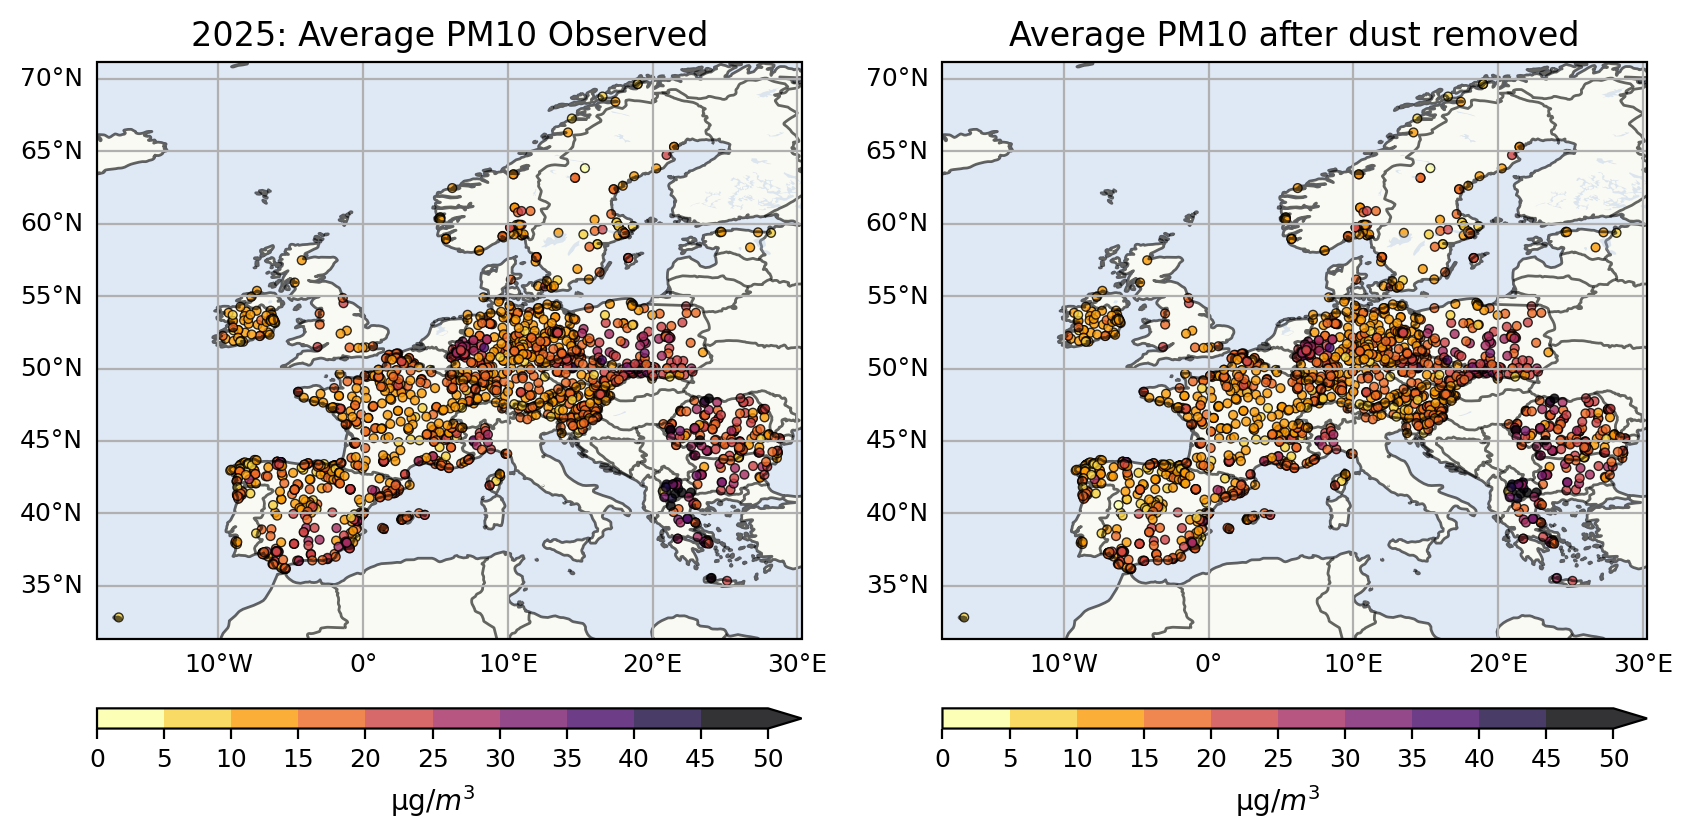

In [85]:
###################Edit here#########################
columns_to_plot = ['Average_PM10', 'Average_PM10_dust_removed']
titles = [
    f'{YEAR}: Average PM10 Observed',
    f'Average PM10 after dust removed'
]
vmax_value = 50
n_colors = 10
colormap='inferno_r' # https://matplotlib.org/stable/gallery/color/colormap_reference.html inferno_r Set1 gist_heat_r twilight
###################Stop here#########################
import cartopy.crs as ccrs
plot_exceedance_maps_discrete(station_table, columns_to_plot, titles, vmax_value,
    cbar_mode="each",                                       # color bar location "each" each plot would be a individual plot or "single" for panel plot
    cbar_orientation="horizontal",gridline = True,
     n_colors=n_colors,cbar_text='µg/$m^3$',cmap_name=colormap,
    cbar_size="3.5%", cbar_pad="12%",
    marker_size = 10 )